# Intro to Logistic Regression

In [1]:
import numpy as np
from scipy.optimize import minimize

from matplotlib import pyplot as plt

# Classification Problems

Now let's take a look at classification problems from a machine learning point of view.  Remember, in classification problems, outputs are discrete.  For now let's consider a 2-class (or *binary class*) example:
$$
y \in \{0, 1\}
$$

## Logistic regression

For the classification problem above, we want a hypothesis (or *predictor*) that obeys:
$$
0 \leq h_\theta(x) \leq 1
$$

We'll make use of the *sigmoid function* (a.k.a. *logistic function*):
$$
g(z) = \frac{1}{1+e^{-z}}
$$

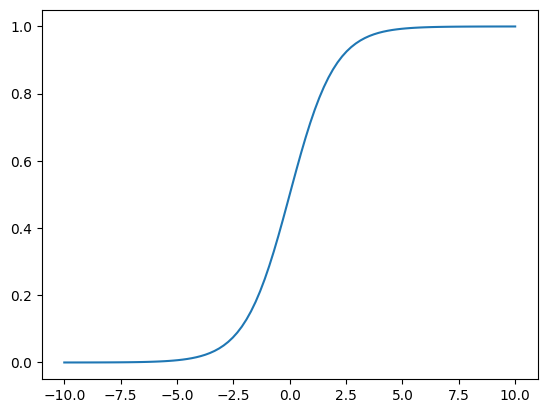

In [2]:
from scipy.special import expit

z = np.linspace(-10, 10, 100)
plt.plot(z, expit(z));

Our hypothesis will be:
$$
h_\theta(x) = g(\theta^Tx) = g(z) = \frac{1}{1+e^{-\theta^Tx}}
$$

So we'll need to fit for parameters $\theta$, which will scale the sigmoid function.

Before we get into learning, let's figure out how to interpret results.  Let's say that we've run the algorithm that we haven't made yet on a training set, and we want to get an estimated output $h_\theta(x)$ at a new input $x$.  Let's think of $h_\theta(x)$ as:

$$
h_\theta(x) = p(y=1|x;\theta),
$$

the probability of $y=1$, given $x$ and trained parameters $\theta$.

Our hypothesis will make use of the sigmoid:
$$
h_\theta(x) = g(\theta^Tx) = g(z) = \frac{1}{1+e^{-\theta^Tx}}
$$

We'll choose a dividing line between the hypothesis preferring one category over the other is $h_\theta(x)=g(\theta^Tx)=.5$

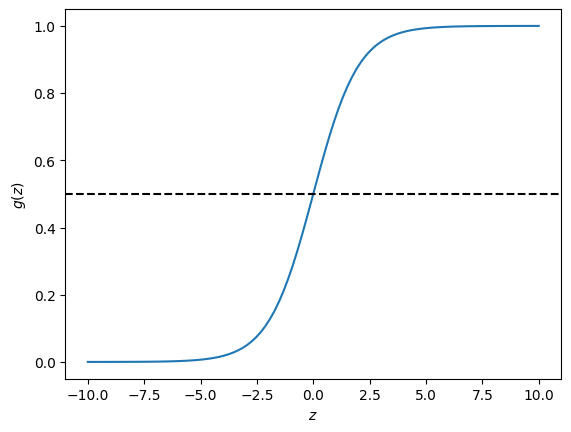

In [3]:
z = np.linspace(-10, 10, 100)
plt.plot(z, expit(z))
plt.axhline(.5, color='k', ls='--')

plt.ylabel(r'$g(z)$')
plt.xlabel(r'$z$');

In other words, when the argument of the sigmoid $z=0$.  So $h_\theta(x) = g(\theta^Tx)\geq0.5$ when $\theta^Tx \geq 0$, which defines a *decision boundary*.

Now let's consider
$$
h_\theta(x) = g(\theta_0 + \theta_1 x_1 + \theta_2 x_2)
$$

This defines our decision boundary, and we predict $y=1$ if
$$
\theta_0 + \theta_1 x_1 + \theta_2 x_2 \geq 0 \\
\theta_1 x_1 + \theta_2 x_2 \geq -\theta_0
$$

So if, say $\theta_0 = -5$, $\theta_1 = 1$, and $\theta_2 = 1$, then we have
$$
x_1 + x_2 \geq 5
$$

So we have a line in $x_1$—$x_2$ space that divides the $y=0$ and $y=1$ regions.

## Non-linear decision boundaries

Just like we could extend the idea of linear regression to polynomial regression, we aren't confined to linear decision boundaries with logistic regression.

Consider the hypothesis:
$$
h_\theta(x) = g(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 + \theta_4 x_2^2)
$$

Let's say $\theta_0 = -1$, $\theta_1 = 0$, $\theta_2 = 0$, $\theta_3 = 1$, and $\theta_4 = 1$.  Then we will predict that $y=1$ if:
$$
-1 + x_1^2 + x_2^2 \geq 0
$$

Giving us a circular decision boundary.  We can go to even higher-order polynomials, allowing a very wide range of shapes for our decision boundary.

## Cost function

We now need to move away from the mean squared error cost function and use a $J(\theta)$ more appropriate for classification problems.  First lets modify our notation a bit for cost functions to be more flexible going forward.

Recall our mean squared error cost function
$$
J(\theta) = \frac{1}{m}\sum_{i=1}^m \frac{1}{2} (h_\theta(x^{(i)}) - y^{(i)})^2
$$

We'll define the term being summed as $\mathrm{Cost}$, and in general this term will be a function of $h_\theta(x^{(i)})$ and $y^{(i)}$ (we'll drop the superscripts for brevity).  So for the case of the mean squared error:
$$
\mathrm{Cost}(h_\theta(x), y) = (h_\theta(x) - y)^2
$$

Now let's consider the following cost function:
$$
\mathrm{Cost}(h_\theta(x), y) = \begin{cases} 
      -\log(h_\theta(x)) ~~~~ & \mathrm{if~} y=1 \\
      -\log(1 - h_\theta(x)) ~~~~ & \mathrm{if~} y=0 \\
   \end{cases}
$$

In [4]:
def cost(h, y):
    if y == 1:
        return -np.log(h)
    else:
        return -np.log(1 - h)

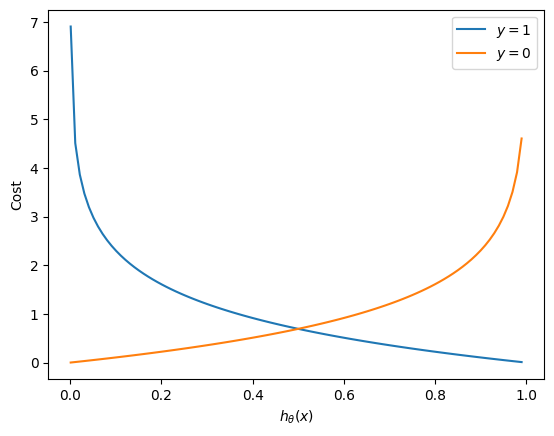

In [5]:
hs = np.linspace(0.001, 1, 100, endpoint=False)

plt.plot(hs, cost(hs, 1), label='$y=1$')
plt.plot(hs, cost(hs, 0), label='$y=0$')

plt.ylabel("Cost")
plt.xlabel(r"$h_\theta(x)$")
plt.legend();

This can be simplified to:
$$
\mathrm{Cost}(h_\theta(x), y) = -y \log(h_\theta(x)) - (1 - y)\log(1 - h_\theta(x))
$$

So our new $J(\theta)$ takes the form
$$
J(\theta) = -\frac{1}{m}\left[\sum_{i=1}^m y^{(i)}\log h_\theta(x^{(i)}) + (1 - y^{(i)})\log (1 - h_\theta(x^{(i)})\right]
$$

As usual, we are looking to find the fit parameters $\hat{\theta}$ that minimize $J(\theta)$, and use our hypothesis
$$
h_{\hat{\theta}}(x) = \frac{1}{1 + e^{-\theta^Tx}},
$$
to predict results for new $x$. Which, again, is interpretted as the probability that $y=1$, $p(y=1|x;\hat{\theta})$.

We can again minimize $J(\theta)$ using gradient decent:

$$
\mathrm{repeat~until~convergence} \{\\
\theta_j = \theta_j - \alpha \frac{\partial}{\partial\theta_j}J(\theta_0, \theta_1) \mathrm{~~~~for~}j=0\mathrm{~and~}j=1
\\\}
$$

A little calculus leads to:
$$
\frac{\partial}{\partial \theta} = \frac{1}{m}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})x_j^{(i)}
$$

which looks identical to the case for linear regression, but remember our $h_\theta(x)$ is different now.

## Vectorized form

Our new $J(\theta)$:
$$
J(\theta) = -\frac{1}{m}\left[\sum_{i=1}^m y^{(i)}\log h_\theta(x^{(i)}) + (1 - y^{(i)})\log (1 - h_\theta(x^{(i)})\right]
$$

is equivalent to the following in vector form:
$$
J(\theta) = -\frac{1}{m}(y^T \log(h) + (1 - y)^T\log(1 - h))
$$

and our hypothesis in vector form:
$$
h = g(X\theta)
$$

Implying the following form for the gradient decent algorithm
$$
\mathrm{repeat~until~convergence} \{\\
\theta := \theta - \frac{\alpha}{m} X^T(g(X\theta)-\vec{y}) \mathrm{~~~~for~}j=0\mathrm{~and~}j=1
\\\}$$

But we're getting to problems that are too complex for our simple gradient decent approach, so we'll start leaning more heavily on more advanced algorithms (e.g., conjugate gradient, BFGS, L-BFGS, powell) for optimization.  We won't go into the details of how these work, so we'll make use of existing implementations.

In [6]:
def cost(h, y):
    if y == 1:
        return -np.log(h)
    else:
        return -np.log(1 - h)

# Linear decision boundary example

Let's look at some public data from the High Time Resolution Universe (HTRU) survey that's looking to find radio pulsars.  The dataset and documentation can be found [here](https://archive.ics.uci.edu/dataset/372/htru2), and more information can be found in [Lyon et al. 2016](https://academic.oup.com/mnras/article/459/1/1104/2608953?login=true).

Identifying a pulsar means fitting the pulse profile in conjunction with the dispersion measure (DM), the number of free electrons along the line of sight that slow down lower-frequency radio waves more than higher frequency ones.  Most pulsar "candidates" are radio frequency interference (RFI).

The task: classify candidate radio signals as either genuine pulsars
(class 1) or noise / RFI (class 0) based on features derived from
the integrated pulse profile and the DM-SNR curve.

Dataset features (8 total):
  1. Mean of the integrated profile
  2. Std deviation of the integrated profile
  3. Excess kurtosis of the integrated profile
  4. Skewness of the integrated profile
  5. Mean of the DM-SNR curve
  6. Std deviation of the DM-SNR curve
  7. Excess kurtosis of the DM-SNR curve
  8. Skewness of the DM-SNR curve
  9. Class (0 = not pulsar, 1 = pulsar)


In [7]:
data_all = np.loadtxt("../data/HTRU_2.csv", delimiter=",")
print(f"Dataset shape: {data_all.shape}")
print(f"  Total samples:       {len(data_all)}")
print(f"  Pulsars (class 1):   {int(data_all[:, -1].sum())}")
print(f"  Non-pulsars (class 0): {int(len(data_all) - data_all[:, -1].sum())}")

Dataset shape: (17898, 9)
  Total samples:       17898
  Pulsars (class 1):   1639
  Non-pulsars (class 0): 16259


We'll start by focusing on features 0 (Profile Mean) and 1 (Profile Std Dev).Let's build your feature matrix $X$ and result training vector $y$.

In [8]:
X_raw = data_all[:, :2]
y = data_all[:, -1].reshape(-1, 1).astype(int)

Let's translate and rescale the features to standardize them (helpful for gradient-based optimatization), and tag on the $1$'s column to make our final design matrix.

In [9]:
mu = X_raw.mean(axis=0)
sigma = X_raw.std(axis=0)
X_scaled = (X_raw - mu) / sigma

# Add intercept column
X = np.column_stack((np.ones(len(X_scaled)), X_scaled))

print(f"Design matrix shape: {X.shape}")

Design matrix shape: (17898, 3)


Finally, let's make a plotting function to visualize the training data, which we'll reuse later.

In [10]:
def plot_data(
    data,
    xlabel="Profile Mean",
    ylabel="Profile Std Dev",
    cat0label="Non-pulsar",
    cat1label="Pulsar",
):
    cat0 = data[:, -1] == 0
    cat1 = data[:, -1] == 1
    plt.scatter(data[cat0][:, 0], data[cat0][:, 1], marker="o", alpha=0.3, s=10, label=cat0label)
    plt.scatter(data[cat1][:, 0], data[cat1][:, 1], marker="+", s=30, label=cat1label)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

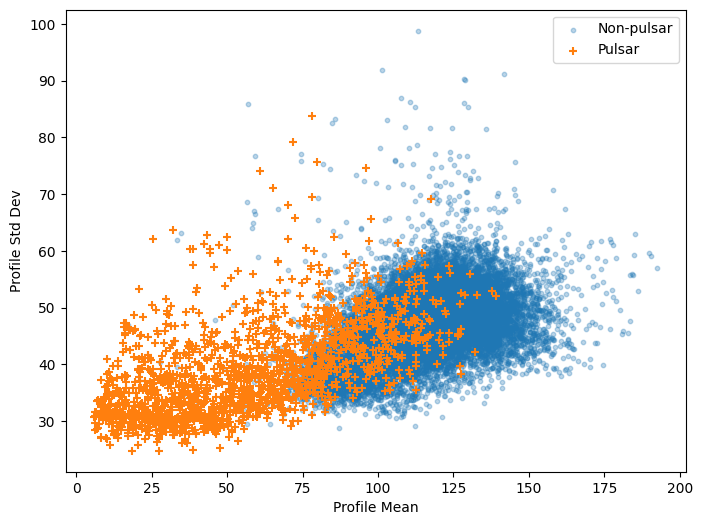

In [11]:
plt.figure(figsize=(8, 6))
plot_data(np.column_stack([X_raw, y]))
plt.legend();

Recall our vectorized form of $J(\theta)$:
$$
J(\theta) = -\frac{1}{m}(y^T \log(h) + (1 - y)^T\log(1 - h))
$$

and sigmoid hypothesis:
$$
h_\theta(x) = g(X\theta)
$$

Let's define our cost function $J(\theta)$ and it's gradient.

In [12]:
def cost(theta, X=X, y=y):
    m = y.size
    h = expit(X.dot(theta))
    
    J = -1/m * (y.T.dot(np.log(h)) + (1 - y).T.dot(np.log(1 - h)))
    J = J[0]
    
    if np.isnan(J):
        return np.inf
    
    return J

Also recall our gradient
$$
\frac{\partial}{\partial \theta} = \frac{1}{m}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})x_j^{(i)}
$$

or, in vector form
$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} X^T(g(X\theta) - y)
$$

**note**: `scipy`'s `minimize` function expects function arguments to be row vectors, so we're going to need to specify our starting point in row-vector form, and make sure the gradient returns a row-vector result.

In [13]:
def cost_gradient(theta, X=X, y=y):
    m = y.size
    h = expit(X.dot(theta.reshape(-1, 1)))
    
    gradient = 1/m * X.T.dot(h - y)
    
    return gradient.flatten()

In [14]:
theta0 = np.zeros(X.shape[1])
print(f"\nStarting theta: {theta0}")
print(f"Initial cost:   {cost(theta0, X, y):.6f}")
print(f"Initial grad:   {cost_gradient(theta0, X, y)}")


Starting theta: [0. 0. 0.]
Initial cost:   0.693147
Initial grad:   [0.40842552 0.19416166 0.1049023 ]


Let's minimize this thing.

In [15]:
res = minimize(cost, theta0, method=None, jac=cost_gradient, options={"maxiter": 400})
theta_opt = res.x.reshape((-1, 1))
print(f"\nOptimisation result:\n{res}")


Optimisation result:
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.11465531200420256
        x: [-4.320e+00 -3.031e+00  2.738e-01]
      nit: 21
      jac: [-1.768e-06  9.883e-07  1.344e-06]
 hess_inv: [[ 8.387e+01  6.588e+01 -5.212e+00]
            [ 6.588e+01  9.272e+01 -2.786e+01]
            [-5.212e+00 -2.786e+01  3.440e+01]]
     nfev: 22
     njev: 22


In [16]:
def h(X, theta=theta_opt):
    return expit(X.dot(theta))

## Decision Boundary

Let's now declare a decesion boundary, and say that we predict $y=1$ if $h_\theta(x) \geq 0.5$.

In [17]:
def predict(X, theta=theta_opt, threshold=0.5):
    p = h(X, theta) >= threshold
    return p.astype('int')

Since our data set is classified, we can assess our training accuracy by seeing how well the model predicts the results from the training data.

In [18]:
p = predict(X)
accuracy = 100 * np.count_nonzero(p == y) / p.size
print(f"\nTraining accuracy (all data, linear): {accuracy:.1f}%")


Training accuracy (all data, linear): 96.7%


Not bad.  Let's see where the decision boundary falls with respect to the data.

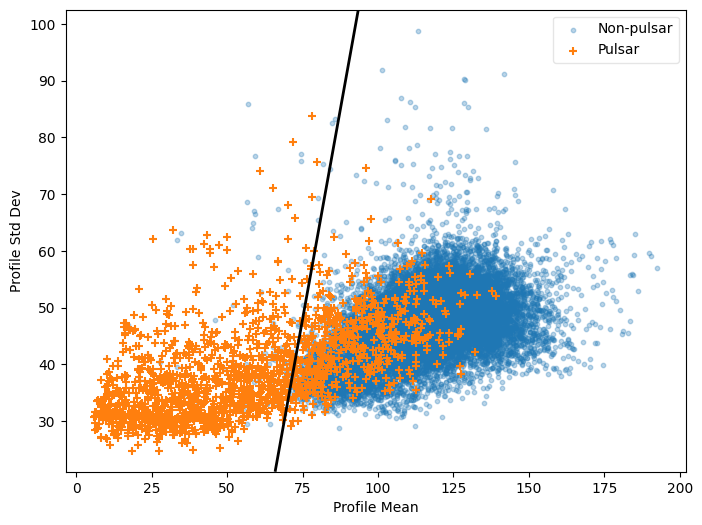

In [19]:
plt.figure(figsize=(8, 6))
plot_data(np.column_stack([X_raw, y]))

# Decision boundary in *scaled* feature space, then map back
x1low, x1high = plt.xlim()
x2low, x2high = plt.ylim()
xx1, xx2 = np.meshgrid(
    np.linspace(x1low, x1high, 200),
    np.linspace(x2low, x2high, 200),
)
# Scale the grid to match the training features
xx1_s = (xx1 - mu[0]) / sigma[0]
xx2_s = (xx2 - mu[1]) / sigma[1]
testX = np.column_stack(
    [np.ones(xx1.ravel().shape[0]), xx1_s.ravel(), xx2_s.ravel()]
)
hh = h(testX).reshape(xx1.shape)
plt.contour(xx1, xx2, hh, [0.5], colors="k", linewidths=2)
plt.legend(framealpha=0.5)

Now lets consider a different hypothesis